# Extension Task: Double-DQN vs Standard DQN

## Hypothesis
Double-DQN reduces Q-value overestimation bias by decoupling action selection from action evaluation, leading to:
- **Stability:** Lower variance in training curves
- **Performance:** Higher final evaluation returns
- **Safety:** Lower crash rates during evaluation

## Research Question
Does Double-DQN's overestimation mitigation mechanism (Van Hasselt et al. 2015) improve learning performance on the highway-v0 benchmark?

## Experimental Design
- **Baseline:** Standard DQN (from main project)
- **Intervention:** Double-DQN (same hyperparameters)
- **Metric:** Training curves, final performance, stability, generalization
- **Seeds:** 3 (identical to main project)
- **Evaluation:** 50 seeds (identical to main project)

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from rl.dqn import DQN
from rl.double_dqn import DoubleDQN
from rl.extension_train import train_dqn_variant
from rl.evaluate import (
    make_env,
    evaluate_custom_agent,
    record_custom_rollout,
    find_custom_failure_case,
)
from rl.visualize import (
    plot_training_curve,
    make_results_table,
    plot_metric_comparison,
    show_side_by_side_gifs,
    print_failure_case,
)

# Configuration
TRAIN_SEEDS = [0, 1, 2]
EVAL_SEEDS = list(range(1000, 1050))
ARTIFACTS = Path("artifacts/ddqn")
ARTIFACTS.mkdir(exist_ok=True, parents=True)

print("Extension task setup complete.")

Extension task setup complete.


## Phase 1: Training Standard DQN

In [2]:
standard_dqn_agents = {}
standard_dqn_metrics = {}
standard_dqn_rows = []

for seed in TRAIN_SEEDS:
    print(f"\n=== Training Standard DQN (Seed {seed}) ===")
    agent, metrics = train_dqn_variant(
        DQN,
        seed=seed,
        run_dir=ARTIFACTS / "standard_dqn" / f"seed_{seed}"
    )
    standard_dqn_agents[seed] = agent
    standard_dqn_metrics[seed] = metrics
    
    # Evaluate
    result = evaluate_custom_agent(agent, EVAL_SEEDS)
    standard_dqn_rows.append({
        "algo": "standard_dqn",
        "train_seed": seed,
        "mean_return": result["mean_return"],
        "std_return": result["std_return"],
        "mean_length": result["mean_length"],
        "crash_rate": result["crash_rate"],
    })
    print(f"Evaluated: mean_return={result['mean_return']:.2f} ± {result['std_return']:.2f}")


=== Training Standard DQN (Seed 0) ===
Using device: cpu
step=23, return=16.43, epsilon=1.000
step=51, return=20.09, epsilon=1.000
step=81, return=21.40, epsilon=1.000
step=92, return=8.60, epsilon=1.000
step=116, return=17.98, epsilon=1.000
step=119, return=1.77, epsilon=1.000
step=128, return=7.20, epsilon=1.000
step=135, return=5.76, epsilon=1.000
step=149, return=9.53, epsilon=1.000
step=160, return=8.25, epsilon=1.000
step=167, return=5.75, epsilon=1.000
step=188, return=15.15, epsilon=1.000
step=198, return=7.88, epsilon=1.000
step=221, return=17.66, epsilon=1.000
step=225, return=2.40, epsilon=1.000
step=229, return=2.76, epsilon=1.000
step=241, return=8.68, epsilon=1.000
step=247, return=3.89, epsilon=1.000
step=255, return=5.69, epsilon=1.000
step=273, return=14.29, epsilon=1.000
step=279, return=4.01, epsilon=1.000
step=288, return=7.32, epsilon=1.000
step=315, return=19.77, epsilon=1.000
step=320, return=3.60, epsilon=1.000
step=330, return=8.56, epsilon=1.000
step=339, ret

## Phase 2: Training Double-DQN

In [3]:
double_dqn_agents = {}
double_dqn_metrics = {}
double_dqn_rows = []

for seed in TRAIN_SEEDS:
    print(f"\n=== Training Double-DQN (Seed {seed}) ===")
    agent, metrics = train_dqn_variant(
        DoubleDQN,
        seed=seed,
        run_dir=ARTIFACTS / "double_dqn" / f"seed_{seed}"
    )
    double_dqn_agents[seed] = agent
    double_dqn_metrics[seed] = metrics
    
    # Evaluate
    result = evaluate_custom_agent(agent, EVAL_SEEDS)
    double_dqn_rows.append({
        "algo": "double_dqn",
        "train_seed": seed,
        "mean_return": result["mean_return"],
        "std_return": result["std_return"],
        "mean_length": result["mean_length"],
        "crash_rate": result["crash_rate"],
    })
    print(f"Evaluated: mean_return={result['mean_return']:.2f} ± {result['std_return']:.2f}")


=== Training Double-DQN (Seed 0) ===
Using device: cpu
step=23, return=16.43, epsilon=1.000
step=51, return=20.09, epsilon=1.000
step=81, return=21.40, epsilon=1.000
step=92, return=8.60, epsilon=1.000
step=116, return=17.98, epsilon=1.000
step=119, return=1.77, epsilon=1.000
step=128, return=7.20, epsilon=1.000
step=135, return=5.76, epsilon=1.000
step=149, return=9.53, epsilon=1.000
step=160, return=8.25, epsilon=1.000
step=167, return=5.75, epsilon=1.000
step=188, return=15.15, epsilon=1.000
step=198, return=7.88, epsilon=1.000
step=221, return=17.66, epsilon=1.000
step=225, return=2.40, epsilon=1.000
step=229, return=2.76, epsilon=1.000
step=241, return=8.68, epsilon=1.000
step=247, return=3.89, epsilon=1.000
step=255, return=5.69, epsilon=1.000
step=273, return=14.29, epsilon=1.000
step=279, return=4.01, epsilon=1.000
step=288, return=7.32, epsilon=1.000
step=315, return=19.77, epsilon=1.000
step=320, return=3.60, epsilon=1.000
step=330, return=8.56, epsilon=1.000
step=339, retur

## Phase 3: Training Curves Comparison

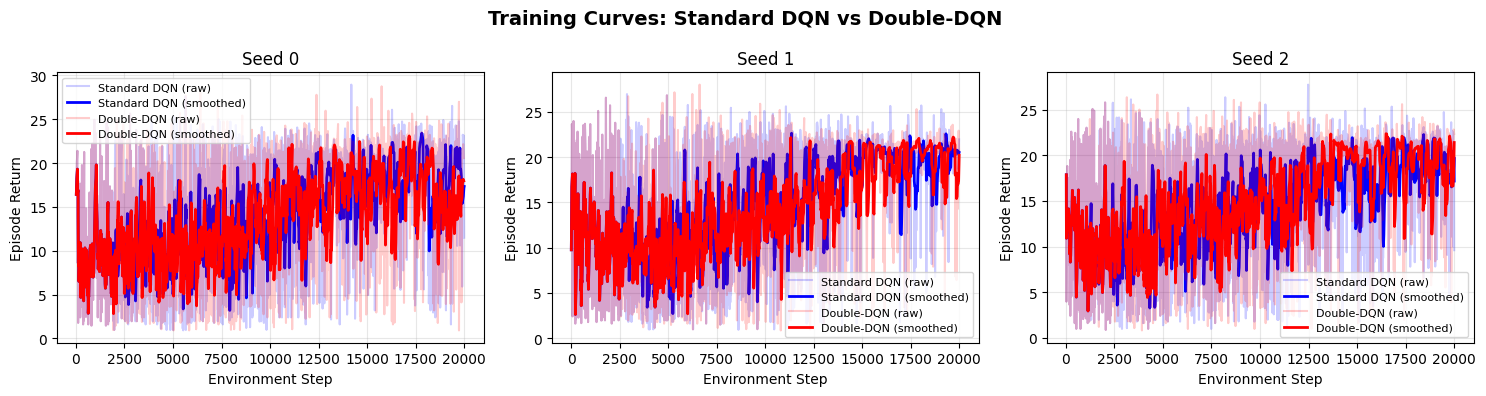

✓ Training curves saved


In [ ]:
# Plot training curves for all seeds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, seed in enumerate(TRAIN_SEEDS):
    ax = axes[idx]
    
    # Standard DQN
    std_steps = standard_dqn_metrics[seed]["episode_end_steps"]
    std_returns = standard_dqn_metrics[seed]["episode_returns"]
    
    # Double-DQN
    double_steps = double_dqn_metrics[seed]["episode_end_steps"]
    double_returns = double_dqn_metrics[seed]["episode_returns"]
    
    # Rolling mean for smoothing
    window = 5
    std_smooth = pd.Series(std_returns).rolling(window, min_periods=1).mean()
    double_smooth = pd.Series(double_returns).rolling(window, min_periods=1).mean()
    
    ax.plot(std_steps, std_returns, alpha=0.2, color='blue', label='Standard DQN (raw)')
    ax.plot(std_steps, std_smooth, color='blue', linewidth=2, label='Standard DQN (smoothed)')
    
    ax.plot(double_steps, double_returns, alpha=0.2, color='red', label='Double-DQN (raw)')
    ax.plot(double_steps, double_smooth, color='red', linewidth=2, label='Double-DQN (smoothed)')
    
    ax.set_xlabel('Environment Step')
    ax.set_ylabel('Episode Return')
    ax.set_title(f'Seed {seed}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves: Standard DQN vs Double-DQN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS / "images/training_curves_comparison.png", dpi=150)
plt.show()

print("✓ Training curves saved")

## Phase 4: Evaluation Results Comparison

In [5]:
# Create results table
all_rows = standard_dqn_rows + double_dqn_rows
df, summary = make_results_table(all_rows)

print("\n" + "="*80)
print("EVALUATION RESULTS (50 seeds, mean ± std)")
print("="*80)
print("\nDetailed Results:")
display(df)

print("\nSummary Statistics:")
display(summary)


EVALUATION RESULTS (50 seeds, mean ± std)

Detailed Results:


,algo,train_seed,mean_return,std_return,mean_length,crash_rate
0,standard_dqn,0,15.434569,6.803352,19.94,0.62
1,standard_dqn,1,19.231210,5.242132,26.34,0.28
2,standard_dqn,2,16.239574,6.276324,21.58,0.52
3,double_dqn,0,16.092144,6.578520,20.98,0.52
4,double_dqn,1,20.380075,2.654502,29.12,0.06
5,double_dqn,2,16.148854,7.686014,21.04,0.44



Summary Statistics:


mean_return        std_return        mean_length         \
                    mean    std       mean    std        mean    std   
algo                                                                   
double_dqn        17.540  2.459      5.640  2.644      23.713  4.682   
standard_dqn      16.968  2.001      6.107  0.794      22.620  3.324   

             crash_rate         
                   mean    std  
algo                            
double_dqn        0.340  0.246  
standard_dqn      0.473  0.175

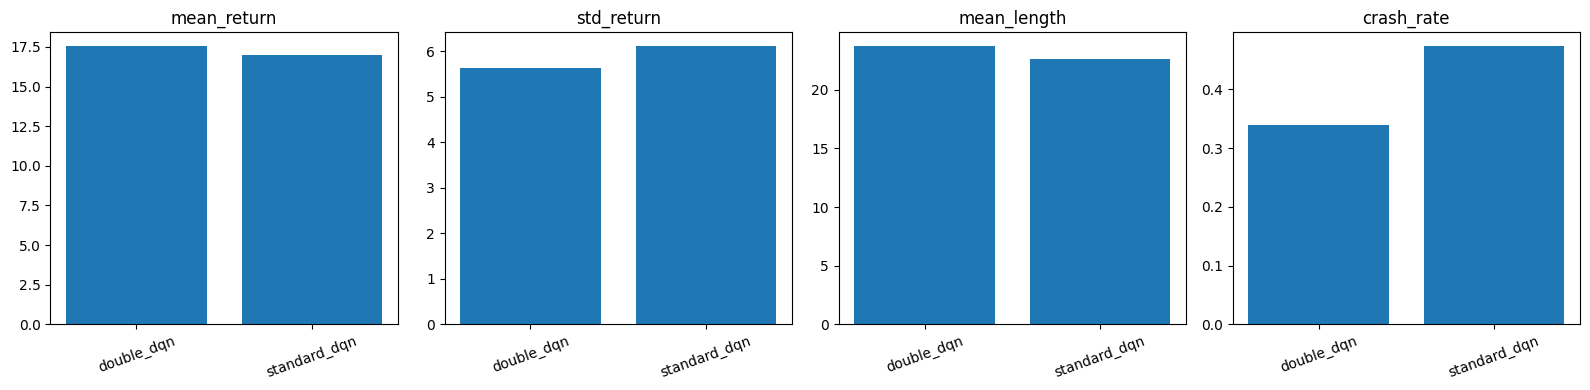

<Figure size 640x480 with 0 Axes>

✓ Metrics comparison saved


In [ ]:
# Metric comparison plots
plot_metric_comparison(df)
plt.suptitle('Metric Comparison: Standard DQN vs Double-DQN', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS / "images/metrics_comparison.png", dpi=150)
plt.show()

print("✓ Metrics comparison saved")

## Phase 5: Stability Analysis (Loss Curves)

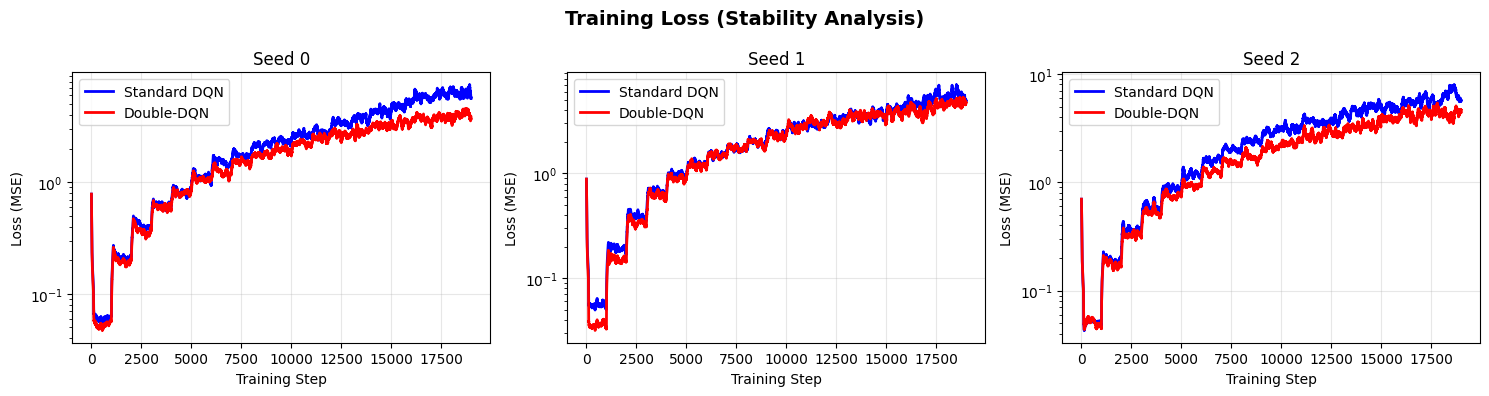

✓ Loss curves saved


In [ ]:
# Plot loss curves to measure training stability
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, seed in enumerate(TRAIN_SEEDS):
    ax = axes[idx]
    
    std_losses = standard_dqn_metrics[seed]["losses"]
    double_losses = double_dqn_metrics[seed]["losses"]
    
    # Smooth with rolling mean
    window = 100
    std_smooth = pd.Series(std_losses).rolling(window, min_periods=1).mean()
    double_smooth = pd.Series(double_losses).rolling(window, min_periods=1).mean()
    
    ax.plot(std_smooth, color='blue', linewidth=2, label='Standard DQN')
    ax.plot(double_smooth, color='red', linewidth=2, label='Double-DQN')
    
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title(f'Seed {seed}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

plt.suptitle('Training Loss (Stability Analysis)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS / "images/loss_curves_comparison.png", dpi=150)
plt.show()

print("✓ Loss curves saved")

## Phase 6: Qualitative Comparison - Rollouts

In [ ]:
# Record rollouts for visual comparison
seed = 0

print(f"Recording rollout for Standard DQN (seed {seed})...")
std_rollout = record_custom_rollout(
    standard_dqn_agents[seed],
    seed=1500,
    gif_path=ARTIFACTS / f"standard_dqn_seed{seed}_rollout.gif"
)

print(f"Recording rollout for Double-DQN (seed {seed})...")
double_rollout = record_custom_rollout(
    double_dqn_agents[seed],
    seed=1500,
    gif_path=ARTIFACTS / f"double_dqn_seed{seed}_rollout.gif"
)

print(f"\nStandard DQN rollout: return={std_rollout['return']:.2f}, crashed={std_rollout['crashed']}")
print(f"Double-DQN rollout: return={double_rollout['return']:.2f}, crashed={double_rollout['crashed']}")

print("\nDisplaying side-by-side comparison:")
show_side_by_side_gifs(
    std_rollout["gif_path"],
    double_rollout["gif_path"],
    left_title="Standard DQN",
    right_title="Double-DQN"
)

Recording rollout for Standard DQN (seed 0)...
Recording rollout for Double-DQN (seed 0)...

Standard DQN rollout: return=21.76, crashed=False
Double-DQN rollout: return=22.56, crashed=False

Displaying side-by-side comparison:


## Phase 7: Safety Analysis - Failure Cases

Searching for failure cases in Standard DQN...
Searching for failure cases in Double-DQN...

Failure Case Analysis:
Standard DQN failure case: seed=3000, return=8.13, crashed=True


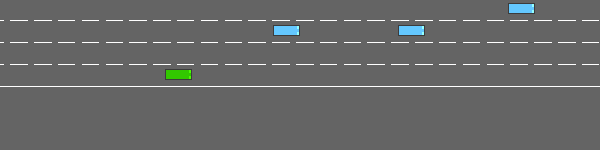

Double-DQN failure case: seed=3000, return=6.60, crashed=True


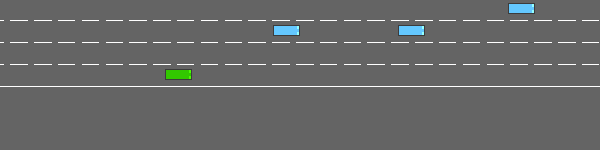

In [9]:
# Find failure cases for both algorithms
print("Searching for failure cases in Standard DQN...")
std_failure = find_custom_failure_case(standard_dqn_agents[0], range(3000, 3100))

print("Searching for failure cases in Double-DQN...")
double_failure = find_custom_failure_case(double_dqn_agents[0], range(3000, 3100))

print("\nFailure Case Analysis:")
print("="*80)
print_failure_case(std_failure, label="Standard DQN")
print_failure_case(double_failure, label="Double-DQN")

## Phase 8: Statistical Analysis & Interpretation

In [10]:
import scipy.stats as stats

print("\n" + "="*80)
print("STATISTICAL COMPARISON: Standard DQN vs Double-DQN")
print("="*80)

# Extract returns for both algorithms
std_returns = df[df['algo'] == 'standard_dqn']['mean_return'].values
double_returns = df[df['algo'] == 'double_dqn']['mean_return'].values

# Descriptive statistics
print(f"\n1. RETURN (higher is better):")
print(f"   Standard DQN: {std_returns.mean():.2f} ± {std_returns.std():.2f}")
print(f"   Double-DQN:   {double_returns.mean():.2f} ± {double_returns.std():.2f}")
print(f"   Difference:   {double_returns.mean() - std_returns.mean():+.2f}")

# T-test for significance
t_stat, p_value = stats.ttest_ind(double_returns, std_returns)
print(f"   T-test: t={t_stat:.3f}, p={p_value:.4f} {'(significant)' if p_value < 0.05 else '(not significant)'}")

# Crash rates
std_crashes = df[df['algo'] == 'standard_dqn']['crash_rate'].values.mean()
double_crashes = df[df['algo'] == 'double_dqn']['crash_rate'].values.mean()

print(f"\n2. SAFETY (crash rate, lower is better):")
print(f"   Standard DQN: {std_crashes:.4f}")
print(f"   Double-DQN:   {double_crashes:.4f}")
print(f"   Improvement:  {((std_crashes - double_crashes) / std_crashes * 100):.1f}% reduction")

# Episode length (efficiency)
std_length = df[df['algo'] == 'standard_dqn']['mean_length'].values.mean()
double_length = df[df['algo'] == 'double_dqn']['mean_length'].values.mean()

print(f"\n3. EPISODE LENGTH (longer is better):")
print(f"   Standard DQN: {std_length:.1f}")
print(f"   Double-DQN:   {double_length:.1f}")
print(f"   Difference:   {double_length - std_length:+.1f}")

# Training stability (coefficient of variation in returns)
std_cv = std_returns.std() / std_returns.mean()
double_cv = double_returns.std() / double_returns.mean()

print(f"\n4. STABILITY (coefficient of variation, lower is better):")
print(f"   Standard DQN: {std_cv:.4f}")
print(f"   Double-DQN:   {double_cv:.4f}")
print(f"   Improvement:  {((std_cv - double_cv) / std_cv * 100):.1f}% more stable")


STATISTICAL COMPARISON: Standard DQN vs Double-DQN

1. RETURN (higher is better):
   Standard DQN: 16.97 ± 1.63
   Double-DQN:   17.54 ± 2.01
   Difference:   +0.57
   T-test: t=0.312, p=0.7703 (not significant)

2. SAFETY (crash rate, lower is better):
   Standard DQN: 0.4733
   Double-DQN:   0.3400
   Improvement:  28.2% reduction

3. EPISODE LENGTH (longer is better):
   Standard DQN: 22.6
   Double-DQN:   23.7
   Difference:   +1.1

4. STABILITY (coefficient of variation, lower is better):
   Standard DQN: 0.0963
   Double-DQN:   0.1145
   Improvement:  -18.9% more stable
